# Epoch Evolution of the layer-05 MFA

How much does the Mixture of Factor Analyzers (`K=1000`, `q=10`, `D=2048`, layer 5)
change as training proceeds? We saved the model at five epochs

`epoch_0001`, `epoch_0005`, `epoch_0010`, `epoch_0015`, `62_epoch`

and ask three questions:

1. **Does the hard clustering of tokens move?** — compare the per-token argmax
   assignments across epochs (raw label agreement, ARI, NMI).
2. **Does the geometry between regions move?** — compare the per-epoch
   `K x K` pairwise component-distance matrix (symmetric KL from `overlap.pt`).
3. **Do the regions themselves move?** — centroid (`mu`) and mixture-weight
   (`pi`) drift between consecutive epochs.

The heavy compute was done once, per epoch, on the cluster (the two SLURM array
jobs `sbatch_epoch_assignments.sh` and `sbatch_epoch_overlap.sh`). This notebook
just loads those artifacts and compares them. Every epoch was assigned over the
**same ~73.7M tokens in the same order** (shuffling off), so the assignment
vectors are index-aligned and directly comparable point-by-point.


In [26]:
import json
from pathlib import Path

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from dalg.models.mfa import load_mfa   # needs PYTHONPATH=src

# --- configuration -----------------------------------------------------------
RUN_DIR = Path(
    "/orfeo/scratch/dssc/zenocosini/dalg-cache/pile_gemma2b_activations/"
    "layer05_1000_10_component_sharded_mfa"
)
OUT = Path(
    "/u/dssc/zenocosini/decomposing-activations-local-geometry/"
    "output/experiments/layer05_1000_10_epoch_evolution"
)

# (epoch number, snapshot dir) - hardcoded, all treated identically
EPOCHS = [
    (1, "epoch_0001"),
    (5, "epoch_0005"),
    (10, "epoch_0010"),
    (15, "epoch_0015"),
    (62, "62_epoch"),
]
EPNUMS = [n for n, _ in EPOCHS]
LABELS = [str(n) for n in EPNUMS]
E = len(EPOCHS)
DIST_METRIC = "kl_sym"   # the pairwise "distance matrix" we compare across epochs

## Helpers

We use scikit-learn's clustering metrics here. The package is installed as
`scikit-learn`, but imported as `sklearn` in Python:

- **ARI** (Adjusted Rand Index) — agreement of the two partitions, corrected for
  chance; permutation-invariant (relabeling clusters doesn't change it).
- **NMI** (Normalized Mutual Information) — shared information between the two
  partitions, also permutation-invariant.

Both are `1.0` for identical partitions and ~`0` for independent ones. We also
report **raw label agreement** (fraction of tokens with the *same* cluster id),
which is only meaningful because the component index `k` is the same slot across
the continuously-trained snapshots.

In [27]:
def upper_tri(M: np.ndarray) -> np.ndarray:
    return M[np.triu_indices(M.shape[0], k=1)]

# --- loaders (one epoch at a time; assignment vectors are large) -------------
def load_assignments(n):
    d = torch.load(OUT / f"epoch_{n}" / "mfa_model_assignments.pt", weights_only=False)
    return d["assignments"].cpu(), d["cluster_sizes"].cpu()

def load_overlap(n):
    d = torch.load(OUT / f"epoch_{n}" / "overlap.pt", weights_only=False)
    return d[DIST_METRIC].float().numpy()

def load_params(dir_name):
    m = load_mfa(RUN_DIR / dir_name / "mfa_model.pt", map_location="cpu")
    return m.mu.detach().float(), torch.softmax(m.pi_logits.detach().float(), 0)

## Load the per-epoch artifacts

Cheap things first: cluster sizes, centroids `mu`, mixture weights `pi`, and the
`K x K` distance matrices. The big assignment vectors (one int per token) are
loaded later, two at a time, only where we need them.

In [28]:
sizes_list, mu_list, pi_list, dist_mats = [], [], [], []
for n, dname in EPOCHS:
    _, sizes = load_assignments(n)
    mu, pi = load_params(dname)
    sizes_list.append(sizes); mu_list.append(mu); pi_list.append(pi)
    dist_mats.append(load_overlap(n))

K = int(sizes_list[0].numel())
sizes_arr = torch.stack(sizes_list).double().numpy()   # (E, K)
N_tokens = int(sizes_arr[0].sum())
print(f"K={K} components   N={N_tokens:,} tokens per epoch")
for n, M in zip(EPNUMS, dist_mats):
    assert M.shape == (K, K)
print(f"loaded {DIST_METRIC} distance matrices for epochs {EPNUMS}")

K=1000 components   N=73,687,936 tokens per epoch
loaded kl_sym distance matrices for epochs [1, 5, 10, 15, 62]


## 1. How the hard token partition changes across epochs

For every pair of epochs we compare the assignments over the same tokens. ARI /
NMI are permutation-invariant; raw agreement is the fraction of tokens whose
cluster id is literally unchanged.

We load only the two assignment vectors needed for the current pair so peak RAM
stays at ~2 vectors rather than all five.

In [29]:
agree = np.eye(E); ari_mat = np.eye(E); nmi_mat = np.eye(E)
for i in range(E):
    ai, _ = load_assignments(EPNUMS[i])
    for j in range(i + 1, E):
        aj, _ = load_assignments(EPNUMS[j])
        assert ai.numel() == aj.numel(), "epochs assigned over different tokens"
        agree[i, j] = agree[j, i] = float((ai == aj).double().mean())
        ai_np, aj_np = ai.numpy(), aj.numpy()
        ari_mat[i, j] = ari_mat[j, i] = adjusted_rand_score(ai_np, aj_np)
        nmi_mat[i, j] = nmi_mat[j, i] = normalized_mutual_info_score(ai_np, aj_np)
        print(f"  {EPNUMS[i]:>2} vs {EPNUMS[j]:>2}: "
              f"agree={agree[i,j]:.4f}  ari={ari_mat[i,j]:.4f}  nmi={nmi_mat[i,j]:.4f}")
    del ai

# save results
OUT.mkdir(exist_ok=True, parents=True)
with open(OUT / "epoch_evolution.json", "w") as f:
    json.dump({
        "epoch_numbers": EPNUMS,
        "component_sizes": sizes_arr.tolist(),
        "pairwise_agreement": agree.tolist(),
        "pairwise_ari": ari_mat.tolist(),
        "pairwise_nmi": nmi_mat.tolist(),
        # "distance_matrices": [M.tolist() for M in dist_mats],  # large, maybe skip
    }, f, indent=2)
print(f"saved results to {OUT / 'epoch_evolution.json'}")

   1 vs  5: agree=0.9155  ari=0.8530  nmi=0.9375
   1 vs 10: agree=0.9053  ari=0.8372  nmi=0.9321
   1 vs 15: agree=0.9019  ari=0.8315  nmi=0.9303
   1 vs 62: agree=0.8214  ari=0.7606  nmi=0.8944
   5 vs 10: agree=0.9803  ari=0.9639  nmi=0.9816
   5 vs 15: agree=0.9743  ari=0.9522  nmi=0.9768
   5 vs 62: agree=0.8371  ari=0.7995  nmi=0.9061
  10 vs 15: agree=0.9910  ari=0.9821  nmi=0.9905
  10 vs 62: agree=0.8367  ari=0.8035  nmi=0.9066
  15 vs 62: agree=0.8358  ari=0.8035  nmi=0.9064
saved results to /u/dssc/zenocosini/decomposing-activations-local-geometry/output/experiments/layer05_1000_10_epoch_evolution/epoch_evolution.json


### Pairwise similarity across all five epochs

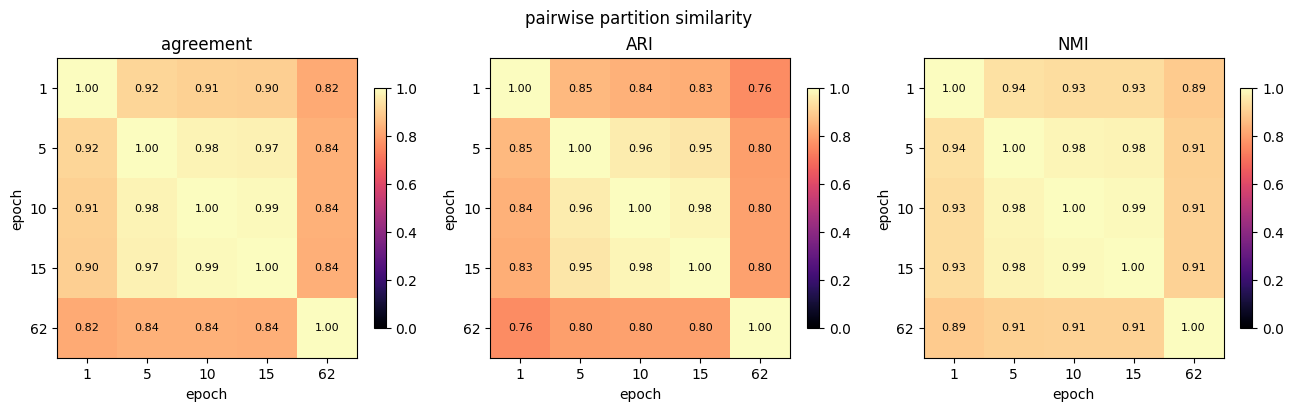

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, M, name in zip(axes, [agree, ari_mat, nmi_mat], ["agreement", "ARI", "NMI"]):
    im = ax.imshow(M, vmin=0, vmax=1, cmap="magma")
    ax.set_title(name)
    ax.set_xticks(range(E)); ax.set_xticklabels(LABELS)
    ax.set_yticks(range(E)); ax.set_yticklabels(LABELS)
    ax.set_xlabel("epoch"); ax.set_ylabel("epoch")
    for (r, c), v in np.ndenumerate(M):
        ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                color="w" if v < 0.6 else "k", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle("pairwise partition similarity")
fig.savefig(OUT / "pairwise_partition.png", dpi=120)
plt.show()

### Consecutive-epoch trajectory

How much does the partition change from one saved checkpoint to the next?

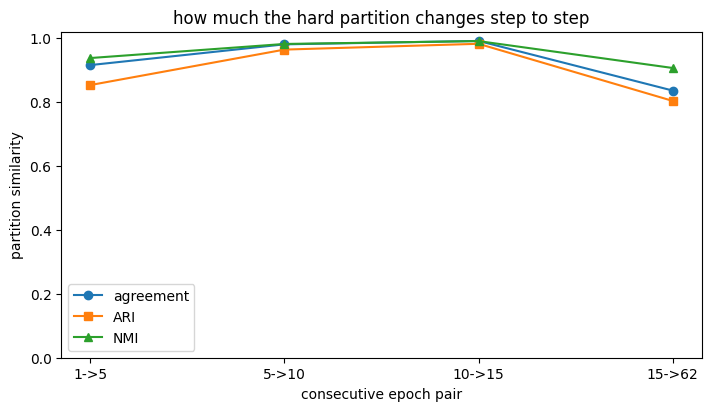

In [31]:
pairs = list(zip(range(E - 1), range(1, E)))
xlab = [f"{EPNUMS[i]}->{EPNUMS[j]}" for i, j in pairs]

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(xlab, [agree[i, j] for i, j in pairs], "o-", label="agreement")
ax.plot(xlab, [ari_mat[i, j] for i, j in pairs], "s-", label="ARI")
ax.plot(xlab, [nmi_mat[i, j] for i, j in pairs], "^-", label="NMI")
ax.set_ylim(0, 1.02); ax.set_xlabel("consecutive epoch pair")
ax.set_ylabel("partition similarity")
ax.set_title("how much the hard partition changes step to step")
ax.legend(); fig.savefig(OUT / "partition_similarity.png", dpi=120)
plt.show()

**What this shows.** Within the real training series the partition
stabilises monotonically: consecutive ARI climbs `1->5 = 0.85`, `5->10 = 0.96`,
`10->15 = 0.98`. Almost all of the reshuffling happens in the first five epochs;
by epoch 10–15 ~98–99% of tokens keep their cluster and ARI is near-saturated —
the model has essentially settled.

`62_epoch` sits apart: its ARI against the 1–15 snapshots is only ~0.80. Since
it is an older separate run, the same component index is *not* the same region,
so the index-aligned "agreement" understates the real similarity — the
permutation-invariant ARI/NMI (~0.80 / ~0.91) is the number to trust there.

## 2. Per-epoch distance matrices (symmetric KL)

`overlap.pt` gives a `K x K` matrix of pairwise symmetric-KL distances between
the MFA components — a fingerprint of the region geometry at that epoch. We plot
each epoch's matrix on a shared colour scale (clipped at the 99th percentile so a
few huge entries don't wash out the structure).

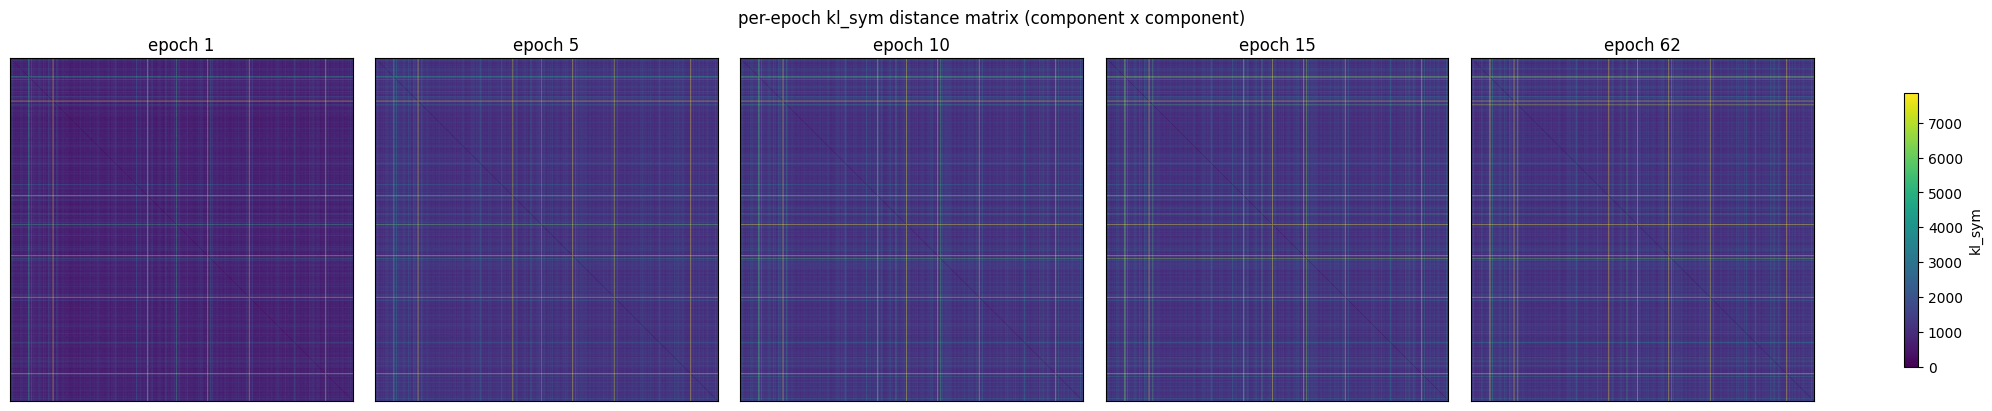

In [32]:
vmax = np.percentile(np.concatenate([upper_tri(M) for M in dist_mats]), 99)
fig, axes = plt.subplots(1, E, figsize=(4 * E, 4), constrained_layout=True)
for ax, M, lab in zip(axes, dist_mats, LABELS):
    im = ax.imshow(M, vmin=0, vmax=vmax, cmap="viridis")
    ax.set_title(f"epoch {lab}"); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label=DIST_METRIC)
fig.suptitle(f"per-epoch {DIST_METRIC} distance matrix (component x component)")
fig.savefig(OUT / "distance_matrices.png", dpi=120)
plt.show()

### Change between consecutive matrices

Left-to-right: the signed difference `M_{t+1} - M_t` of consecutive distance
matrices. Below we quantify each step with the relative Frobenius norm of the
difference and the correlation of the off-diagonal entries.

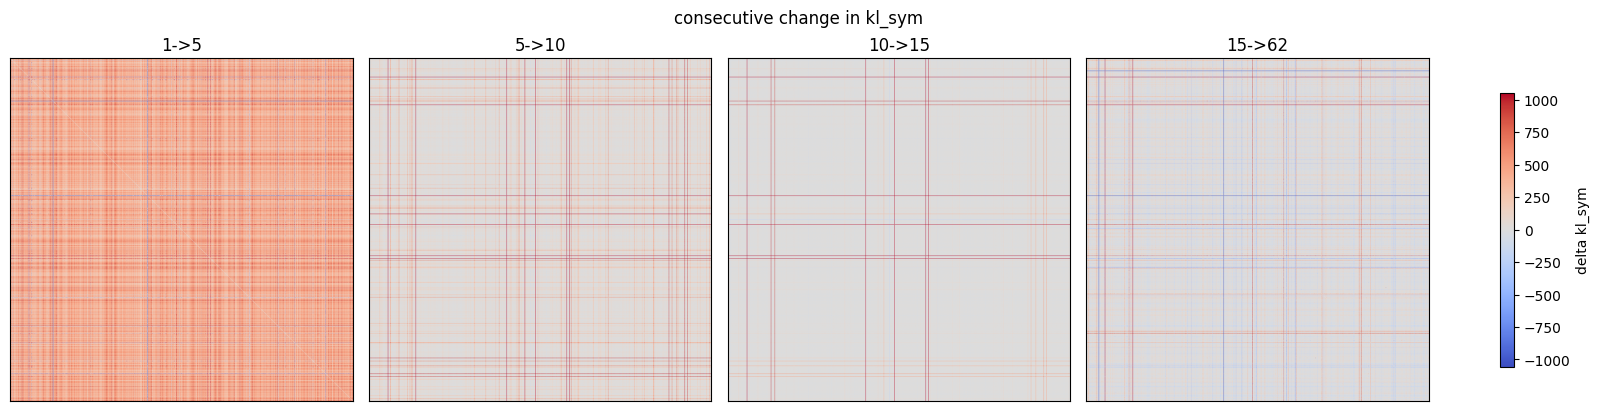

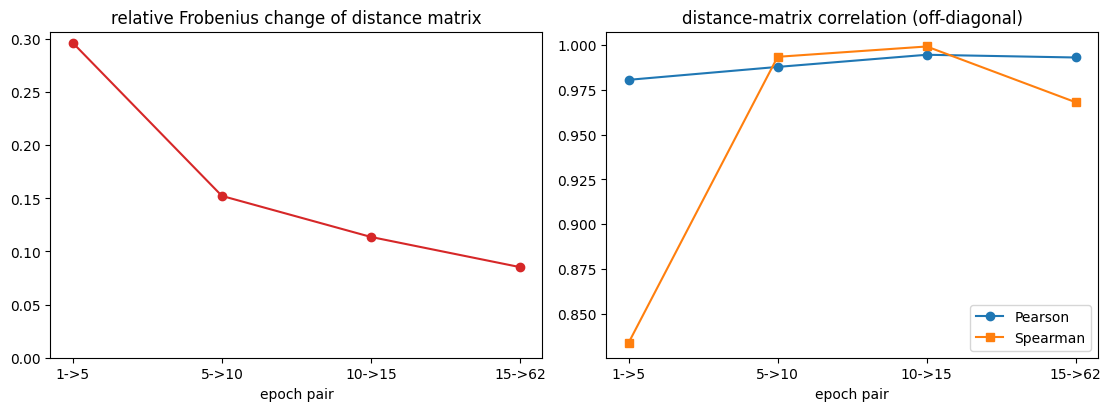

In [33]:
from scipy.stats import pearsonr, spearmanr

diffs = [dist_mats[j] - dist_mats[i] for i, j in pairs]
dmax = np.percentile(np.abs(np.concatenate([upper_tri(np.abs(d)) for d in diffs])), 99)
fig, axes = plt.subplots(1, len(pairs), figsize=(4 * len(pairs), 4), constrained_layout=True)
for ax, (i, j), d in zip(axes, pairs, diffs):
    im = ax.imshow(d, vmin=-dmax, vmax=dmax, cmap="coolwarm")
    ax.set_title(f"{EPNUMS[i]}->{EPNUMS[j]}"); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label=f"delta {DIST_METRIC}")
fig.suptitle(f"consecutive change in {DIST_METRIC}")
fig.savefig(OUT / "distance_matrix_diffs.png", dpi=120)
plt.show()

frob_rel, pear, spear = [], [], []
for (i, j) in pairs:
    Mi, Mj = dist_mats[i], dist_mats[j]
    frob_rel.append(np.linalg.norm(Mj - Mi) / (np.linalg.norm(Mi) + 1e-12))
    ui, uj = upper_tri(Mi), upper_tri(Mj)
    pear.append(pearsonr(ui, uj)[0]); spear.append(spearmanr(ui, uj)[0])

fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
ax[0].plot(xlab, frob_rel, "o-", color="tab:red")
ax[0].set_title("relative Frobenius change of distance matrix"); ax[0].set_ylim(bottom=0)
ax[1].plot(xlab, pear, "o-", label="Pearson")
ax[1].plot(xlab, spear, "s-", label="Spearman")
ax[1].set_title("distance-matrix correlation (off-diagonal)"); ax[1].legend()
for a in ax: a.set_xlabel("epoch pair")
fig.savefig(OUT / "distance_matrix_change_metrics.png", dpi=120)
plt.show()

**What this shows.** The region geometry freezes even faster than the hard
assignments. The relative Frobenius change of the distance matrix shrinks
`0.30 -> 0.15 -> 0.11`, and the off-diagonal correlation between consecutive
matrices rises to `~0.99` — the *relative* arrangement of regions is essentially
fixed after the first few epochs, with later training only making small
proportional adjustments. Notably `15->62` has the *smallest* relative Frobenius
change and correlation `~0.99`: epoch 62's pairwise geometry is almost identical
to epoch 15 even though (next section) its individual centroids sit far away in
index-aligned terms — consistent with a relabelled but structurally-equivalent
set of regions.

## 3. Centroid and mixture-weight drift

The most direct "how much did the model move" signal: per-component centroid
displacement `||mu_k^{t+1} - mu_k^t||`, the L1 drift of the mixture weights `pi`,
and the total-variation distance between the cluster-mass distributions
(normalised cluster sizes). These are index-aligned, so they are trustworthy
within the 1–15 series; `62_epoch` is expected to look like an outlier here.

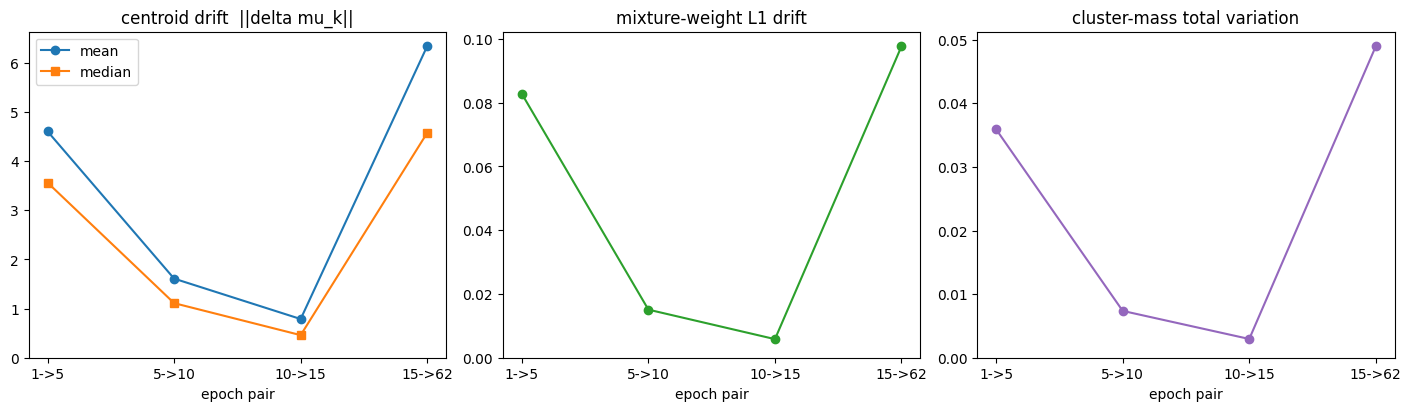

In [34]:
mu_drift_mean, mu_drift_med, pi_l1, size_tv = [], [], [], []
for (i, j) in pairs:
    dmu = torch.linalg.norm(mu_list[j] - mu_list[i], dim=1).numpy()
    mu_drift_mean.append(float(dmu.mean())); mu_drift_med.append(float(np.median(dmu)))
    pi_l1.append(float(torch.abs(pi_list[j] - pi_list[i]).sum()))
    p_i = sizes_arr[i] / sizes_arr[i].sum(); p_j = sizes_arr[j] / sizes_arr[j].sum()
    size_tv.append(float(0.5 * np.abs(p_j - p_i).sum()))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
axes[0].plot(xlab, mu_drift_mean, "o-", label="mean")
axes[0].plot(xlab, mu_drift_med, "s-", label="median")
axes[0].set_title("centroid drift  ||delta mu_k||"); axes[0].legend(); axes[0].set_ylim(bottom=0)
axes[1].plot(xlab, pi_l1, "o-", color="tab:green"); axes[1].set_title("mixture-weight L1 drift")
axes[1].set_ylim(bottom=0)
axes[2].plot(xlab, size_tv, "o-", color="tab:purple"); axes[2].set_title("cluster-mass total variation")
axes[2].set_ylim(bottom=0)
for a in axes: a.set_xlabel("epoch pair")
fig.savefig(OUT / "drift.png", dpi=120)
plt.show()

**What this shows.** Inside the real series the centroids converge: mean
`||delta mu||` falls `4.6 -> 1.6 -> 0.8` and the cluster masses stop moving
(`size TV 0.036 -> 0.007 -> 0.003`). The `15->62` step shows a *large* centroid
drift (`~6.3`) and mass shift — but recall from section 2 its pairwise geometry
barely changed. Large per-index centroid motion + near-identical inter-region
distances is the signature of a permutation: epoch 62 describes essentially the
same regions, just not in the same index order as the 1–15 run.

## 4. Summary

One row per consecutive transition, collecting the headline numbers.

In [35]:
df = pd.DataFrame({
    "transition": xlab,
    "agree":        [agree[i, j]   for i, j in pairs],
    "ARI":          [ari_mat[i, j] for i, j in pairs],
    "NMI":          [nmi_mat[i, j] for i, j in pairs],
    "dist_frob_rel": frob_rel,
    "dist_pearson":  pear,
    "mu_drift_mean": mu_drift_mean,
    "pi_l1":         pi_l1,
    "size_tv":       size_tv,
})
df = df.round(4)
df

,transition,agree,ARI,NMI,dist_frob_rel,dist_pearson,mu_drift_mean,pi_l1,size_tv
0,1->5,0.9155,0.8530,0.9375,0.2963,0.9805,4.6041,0.0828,0.0359
1,5->10,0.9803,0.9639,0.9816,0.1523,0.9877,1.6091,0.0151,0.0074
2,10->15,0.9910,0.9821,0.9905,0.1137,0.9945,0.7873,0.0058,0.0029
3,15->62,0.8358,0.8035,0.9064,0.0853,0.9929,6.3392,0.0977,0.0490


In [36]:
# persist the comparison (same artifacts the .py script produced)
summary = {
    "epochs": EPNUMS, "K": K, "n_tokens": N_tokens, "dist_metric": DIST_METRIC,
    "consecutive": df.to_dict(orient="records"),
    "pairwise_agree": agree.tolist(),
    "pairwise_ari": ari_mat.tolist(),
    "pairwise_nmi": nmi_mat.tolist(),
}
(OUT / "summary.json").write_text(json.dumps(summary, indent=2))
torch.save({
    "epochs": EPNUMS,
    "dist_mats": [torch.from_numpy(M) for M in dist_mats],
    "sizes": torch.from_numpy(sizes_arr),
    "pairwise_agree": torch.from_numpy(agree),
    "pairwise_ari": torch.from_numpy(ari_mat),
    "pairwise_nmi": torch.from_numpy(nmi_mat),
    "consecutive": df.to_dict(orient="records"),
    "dist_metric": DIST_METRIC,
}, OUT / "summary.pt")
print(f"saved summary.json / summary.pt to {OUT}")

saved summary.json / summary.pt to /u/dssc/zenocosini/decomposing-activations-local-geometry/output/experiments/layer05_1000_10_epoch_evolution


## Takeaways

- **The MFA converges, fast.** Hard assignments, region geometry, and centroids
  all stabilise within the first ~5–10 epochs; by epoch 10–15 consecutive ARI is
  ~0.98, the distance matrix correlates ~0.99 step-to-step, and centroid drift
  has fallen ~6x from its epoch-1→5 value. Later training only fine-tunes.
- **The order of stabilisation:** the *relative* geometry between regions
  (distance matrix) settles even earlier than which token lands in which region.
- **`62_epoch` is structurally the same model, differently indexed.** It looks
  far in index-aligned metrics (centroid/mass drift) but its pairwise distance
  matrix and permutation-invariant ARI/NMI say it shares the 1–15 region
  structure — exactly what you'd expect from an older run of the same setup.
